# 5 - Neo-Riemannian Transformations

In [426]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [428]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21
import re

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia
from Importables import tonnetz_utils as t

In [430]:
metadata = g.load_metadata()

## Test: One piece

In [433]:
test = metadata[metadata['fnames'] == 'Final Thought - Kamasi Washington']
labels = g.load_labels(test)
labels.head() 

,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,staff,voice,harmony_layer,label,regex_match,artist,workTitle,fnames,rel_paths,recording_year,time,ILS
0,1,1,0,0,116.0,0.0,0,2/2,1,1,3,Dm,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,1.0,"[D, F, A]"
1,30,30,116,116,8.0,0.0,0,2/2,1,1,3,E-,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,30.0,"[E-, G, B-]"
2,32,32,124,124,8.0,0.0,0,2/2,1,1,3,Dm,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,32.0,"[D, F, A]"
3,34,34,132,132,8.0,0.0,0,2/2,1,1,3,E-,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,34.0,"[E-, G, B-]"
4,36,36,140,140,8.0,0.0,0,2/2,1,1,3,F,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,36.0,"[F, A, C]"


In [435]:
transformations, exceptions = t.transformation(labels)
transformations.value_counts(subset=['transformation']).reset_index(name='count')

,transformation,count
0,N/A,14
1,N,2
2,R,2


## All :)))))

In [438]:
labels = g.load_labels(metadata)
transformations, exceptions = t.transformation(labels) 

In [439]:
transformations.value_counts(subset=['transformation']).reset_index(name='count') 

,transformation,count
0,N/A,17804
1,N,3030
2,P,835
3,R,376
4,H,296
5,L,205
6,S,189


### N/A Transformations

For NA pairs that are both major/minor, look for two transformations and make new categories for them

In [441]:
NA = transformations[transformations['transformation'] == 'N/A']
NA.value_counts(subset=['chord_1', 'chord_2']).reset_index(name='count').head(15) 

,chord_1,chord_2,count
0,Cm7,F7,691
1,Gm7,C7,615
2,Fm7,B-7,537
3,B-7,E-M7,514
4,Dm7,G7,472
5,Am7,D7,377
6,B-m7,E-7,364
7,C7,FM7,362
8,F7,B-7,350
9,F7,B-M7,306


### Exceptions

In [443]:
exceptions_count = labels[labels['label'].isin(exceptions)].value_counts(subset=['label']).reset_index(name='count')
exceptions_count.head(10)

,label,count
0,Cm69,134
1,E13no3,27
2,F13no3,27
3,E-13no3,15
4,G#dim,14
5,D13sus4,13
6,Edim,11
7,Do,8
8,A-9sus4,6
9,D-M7no5,6


### Group by year

In [448]:
transformations = transformations[transformations['recording_year'].notna()].copy()
transformations['year_bin'] = pd.cut(transformations['recording_year'], bins=bins, labels=bin_labels, right=False)

In [450]:
transformations_cut = transformations[transformations['transformation'] != 'N/A'].copy()

<function matplotlib.pyplot.show(close=None, block=None)>

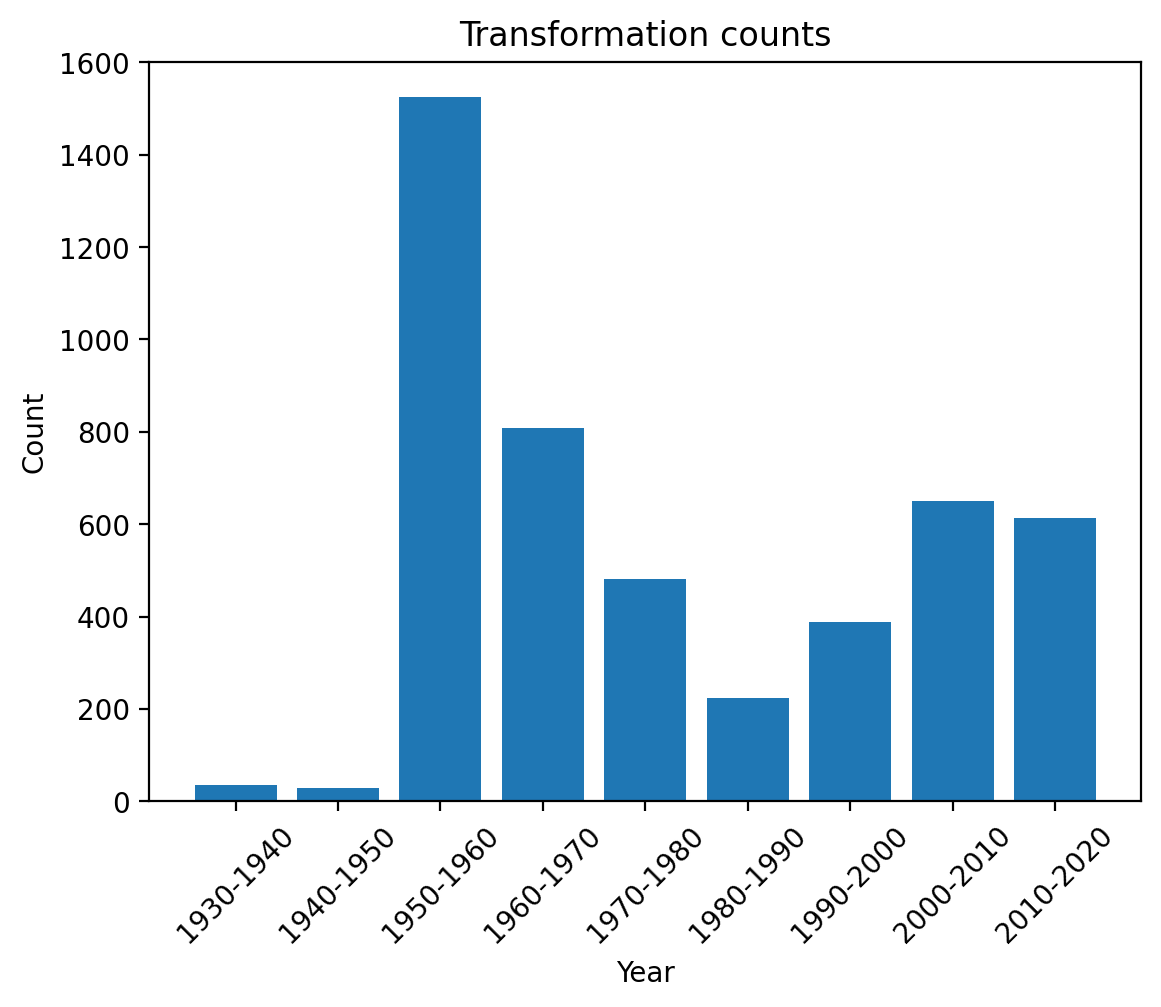

In [452]:
transformations_cut['year_bin'] = pd.Categorical(transformations_cut['year_bin'], categories=bin_labels, ordered=True)
counts = transformations_cut.value_counts(subset=['year_bin']).reset_index(name='count')
counts = counts.sort_values('year_bin')
y = counts['count']
x = counts['year_bin']
plt.bar(x, y)
plt.title('Transformation counts')
plt.ylabel('Count')
plt.xlabel('Year')
plt.xticks(x,rotation=45)
plt.show


2010-2020: snum: [  29    6 1082  559  278  137  197  280  383]
2010-2020: snum: [  4  21 152  95 103  60  68 232  50]
2010-2020: snum: [ 2  0 82 50 71 23 32 56 49]
2010-2020: snum: [ 0  0 68 28 16  3 47 31 71]
2010-2020: snum: [ 0  1 78 34  5  0 13 29 45]
2010-2020: snum: [ 0  0 62 43  8  0 32 22 16]


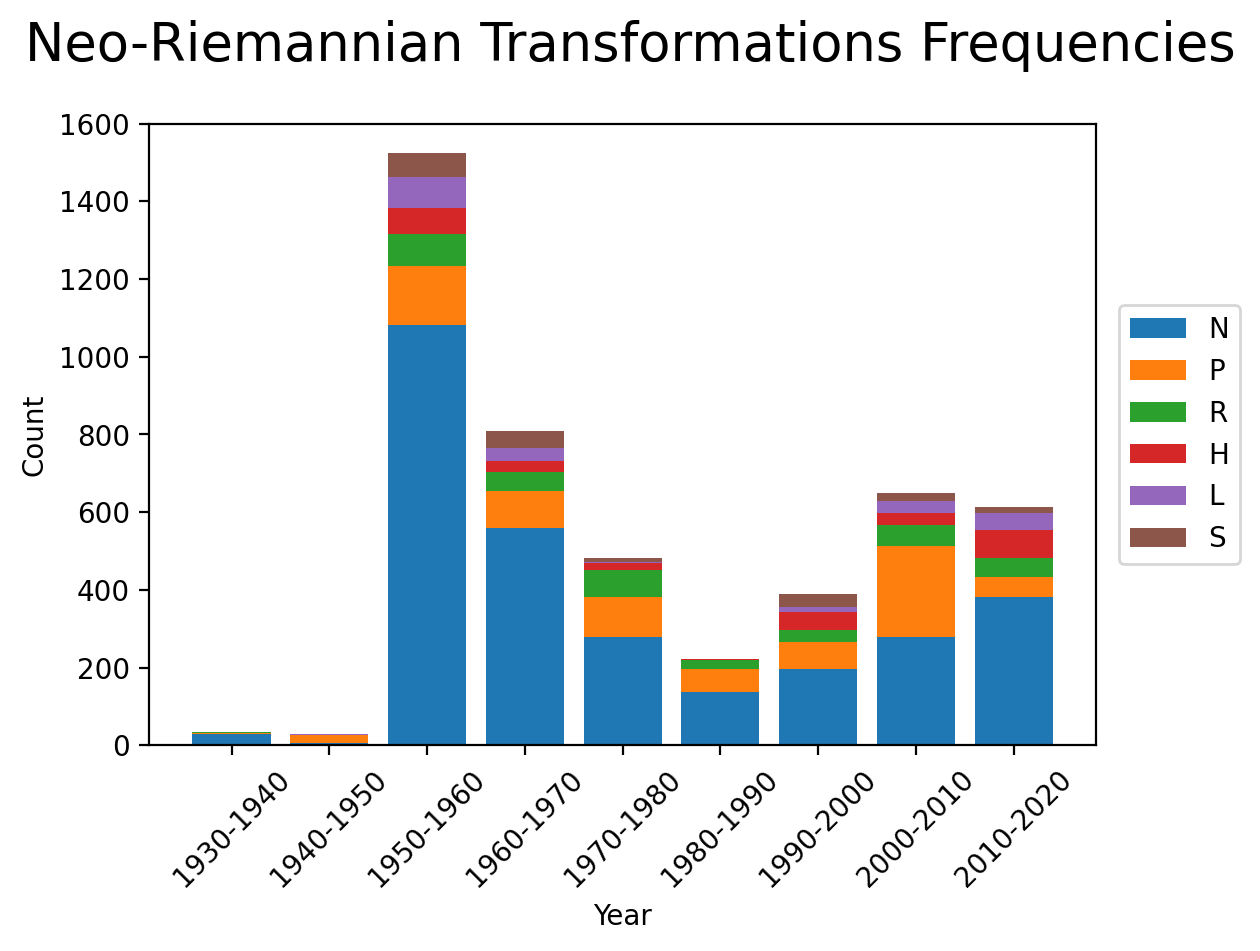

In [454]:
x = bin_labels
num_bins = len(x)

fig, ax = plt.subplots()
current_itn = np.zeros(num_bins)

for transformation in transformations_cut.value_counts(subset=['transformation']).reset_index(name='count')['transformation']:
    transformation_subset = transformations_cut[transformations_cut['transformation']== transformation]
    transformations_subset_grouped = (
        transformation_subset.groupby('year_bin')
        .size()
        .reindex(x, fill_value=0)
        .reset_index(name='count')
    )
    
    y = transformations_subset_grouped['count'] 
    y = np.array(y)
    print(f"{years}: snum: {y}")

    ax.bar(x, y, bottom = current_itn, label=transformation)

    current_itn = current_itn + y

    ax.set_xticks(np.arange(num_bins))
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')
    ax.set_xticklabels(x,rotation=45)

plt.suptitle('Neo-Riemannian Transformations Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
#plt.savefig(f"../Results/NotesPerChordMajor")
plt.show()

In [704]:
def plot(transformation, y='Percent'):
    P_results = []
    
    for years in bin_labels:
        subset_year = transformations_cut[transformations_cut['year_bin'] == years]
        tot_count = subset_year.shape[0]
        # bootstrap
        sample_mean = []
        for i in range(100):
            sub_samp = subset_year.sample(frac=1, replace=True)
            if isinstance(transformation, str):
                P_count = sub_samp[sub_samp['transformation'] == transformation].shape[0]
            if isinstance(transformation, list):
                P_count = sub_samp[sub_samp['transformation'].isin(transformation)].shape[0]

            if y == 'Percent':
                avg = 100 * P_count / tot_count
                sample_mean.append(avg)
            if y == 'Count':
                sample_mean.append(P_count)
    
        mean_estimate = np.mean(sample_mean)
        ci_lower = np.percentile(sample_mean, 2.5)
        ci_upper = np.percentile(sample_mean, 97.5)
    
        P_results.append({
            'year_bin': years,
            'mean': mean_estimate,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper
        })
        
    P_results = pd.DataFrame(P_results)
    
    yerr = [
        P_results['mean'] - P_results['ci_lower'],
        P_results['ci_upper'] - P_results['mean']
    ]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.errorbar(P_results['year_bin'], P_results['mean'], yerr=yerr, capsize=5, color='skyblue')
    
    ax.set_xlabel('Year')
    if y == 'Percent':
        ax.set_ylabel(f'% of {transformation} Transformations')
    if y == 'Count':
        ax.set_ylabel(f'Count of {transformation} Transformations')
        
    ax.set_title(f'Bootstrap Estimates of {transformation} Transformation Proportions with 95% CIs')
    #ax.set_ylim(0, 100)
    ax.set_xticklabels(P_results['year_bin'], rotation=45)
    
    plt.tight_layout()
    plt.savefig(f"../Results/{transformation}Transformation")
    plt.show()

    return P_results['mean']

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_61742/10318916.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(P_results['year_bin'], rotation=45)


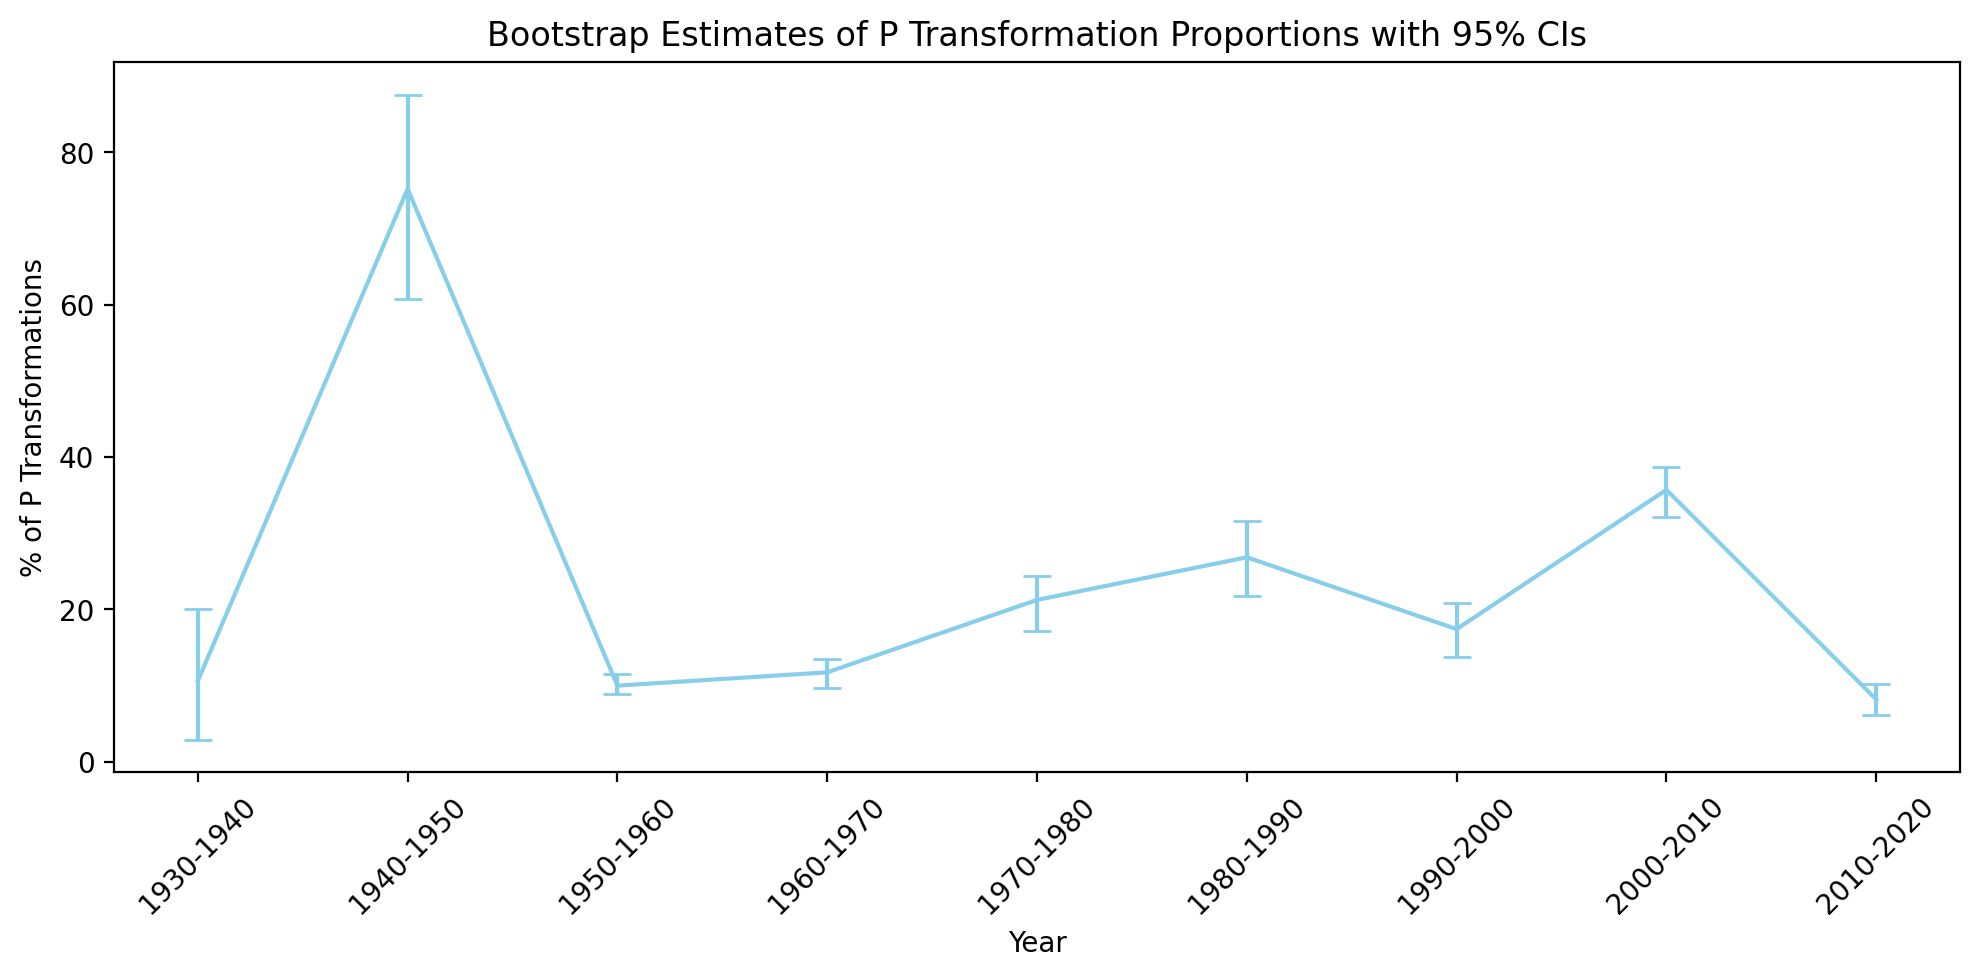

In [706]:
P = plot('P')

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_61742/10318916.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(P_results['year_bin'], rotation=45)


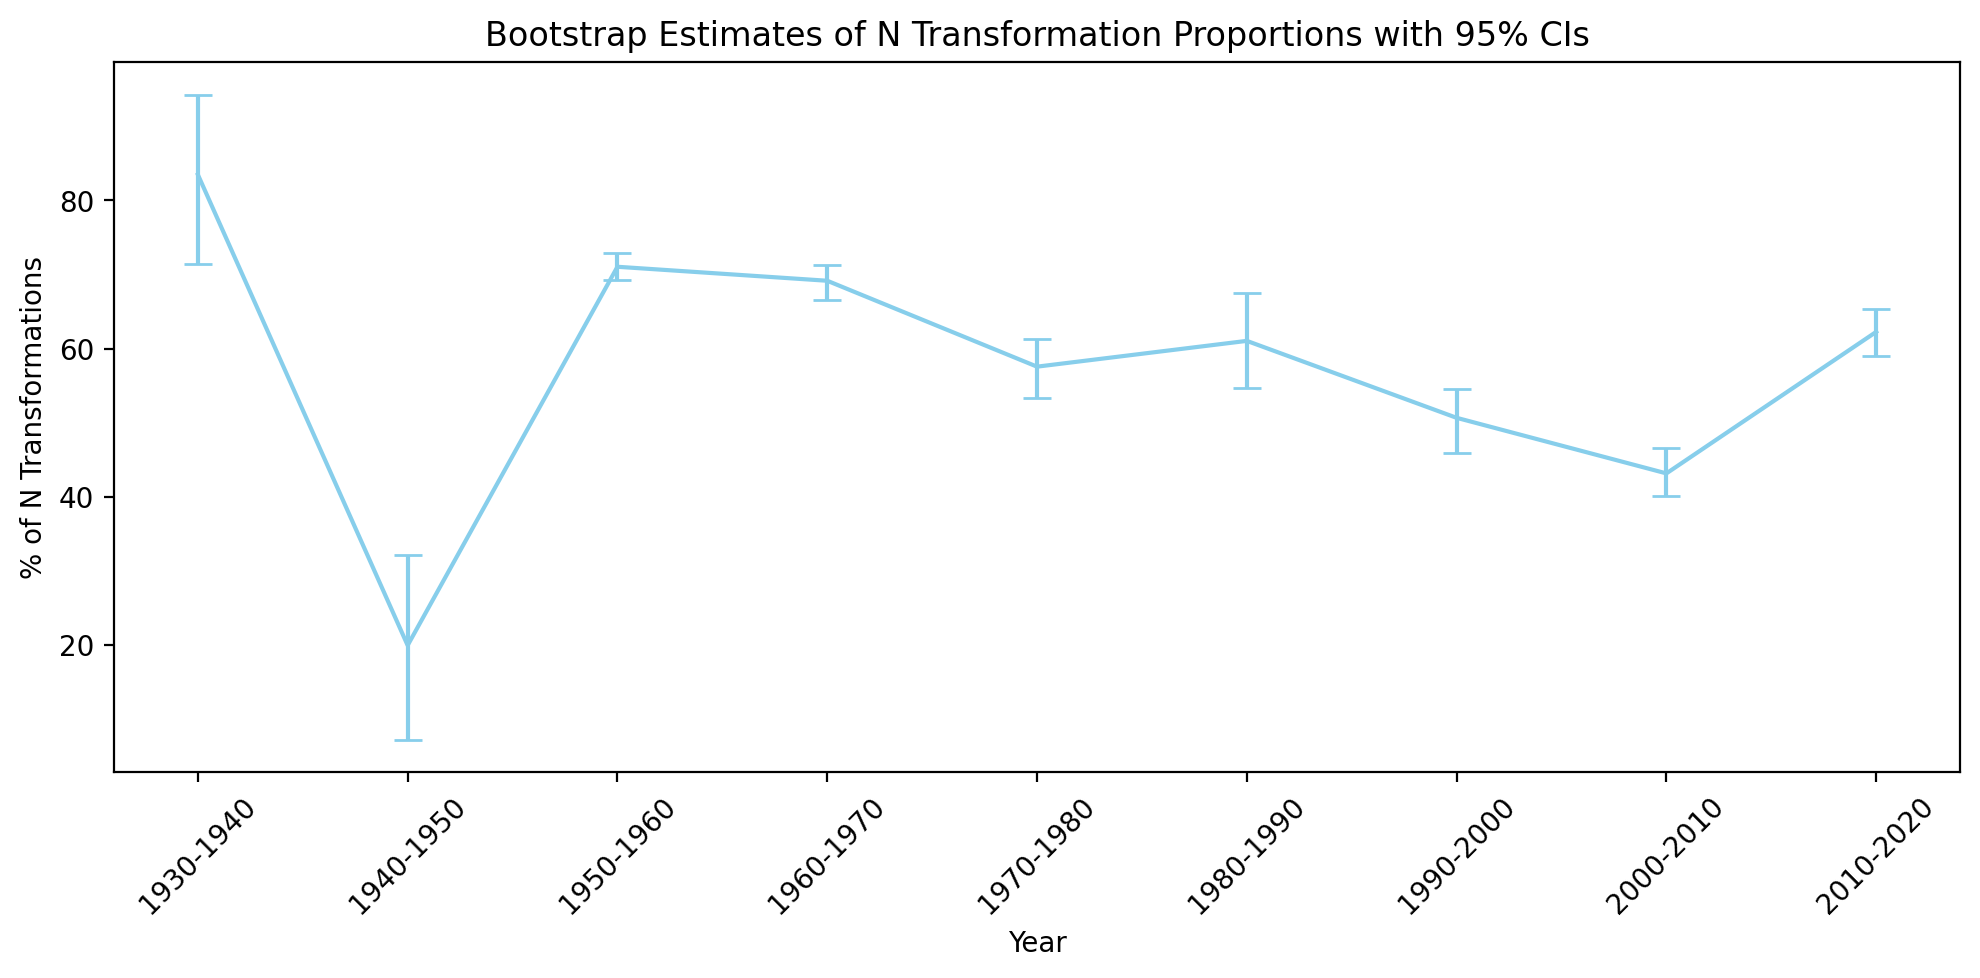

In [707]:
N = plot('N')

In [710]:
from scipy.stats import spearmanr
correlation, p_value = spearmanr(N, P)
print("Spearman correlation:", correlation)
print("p-value:", p_value)

Spearman correlation: -0.8166666666666667
p-value: 0.007224785246358786


/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_61742/10318916.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(P_results['year_bin'], rotation=45)


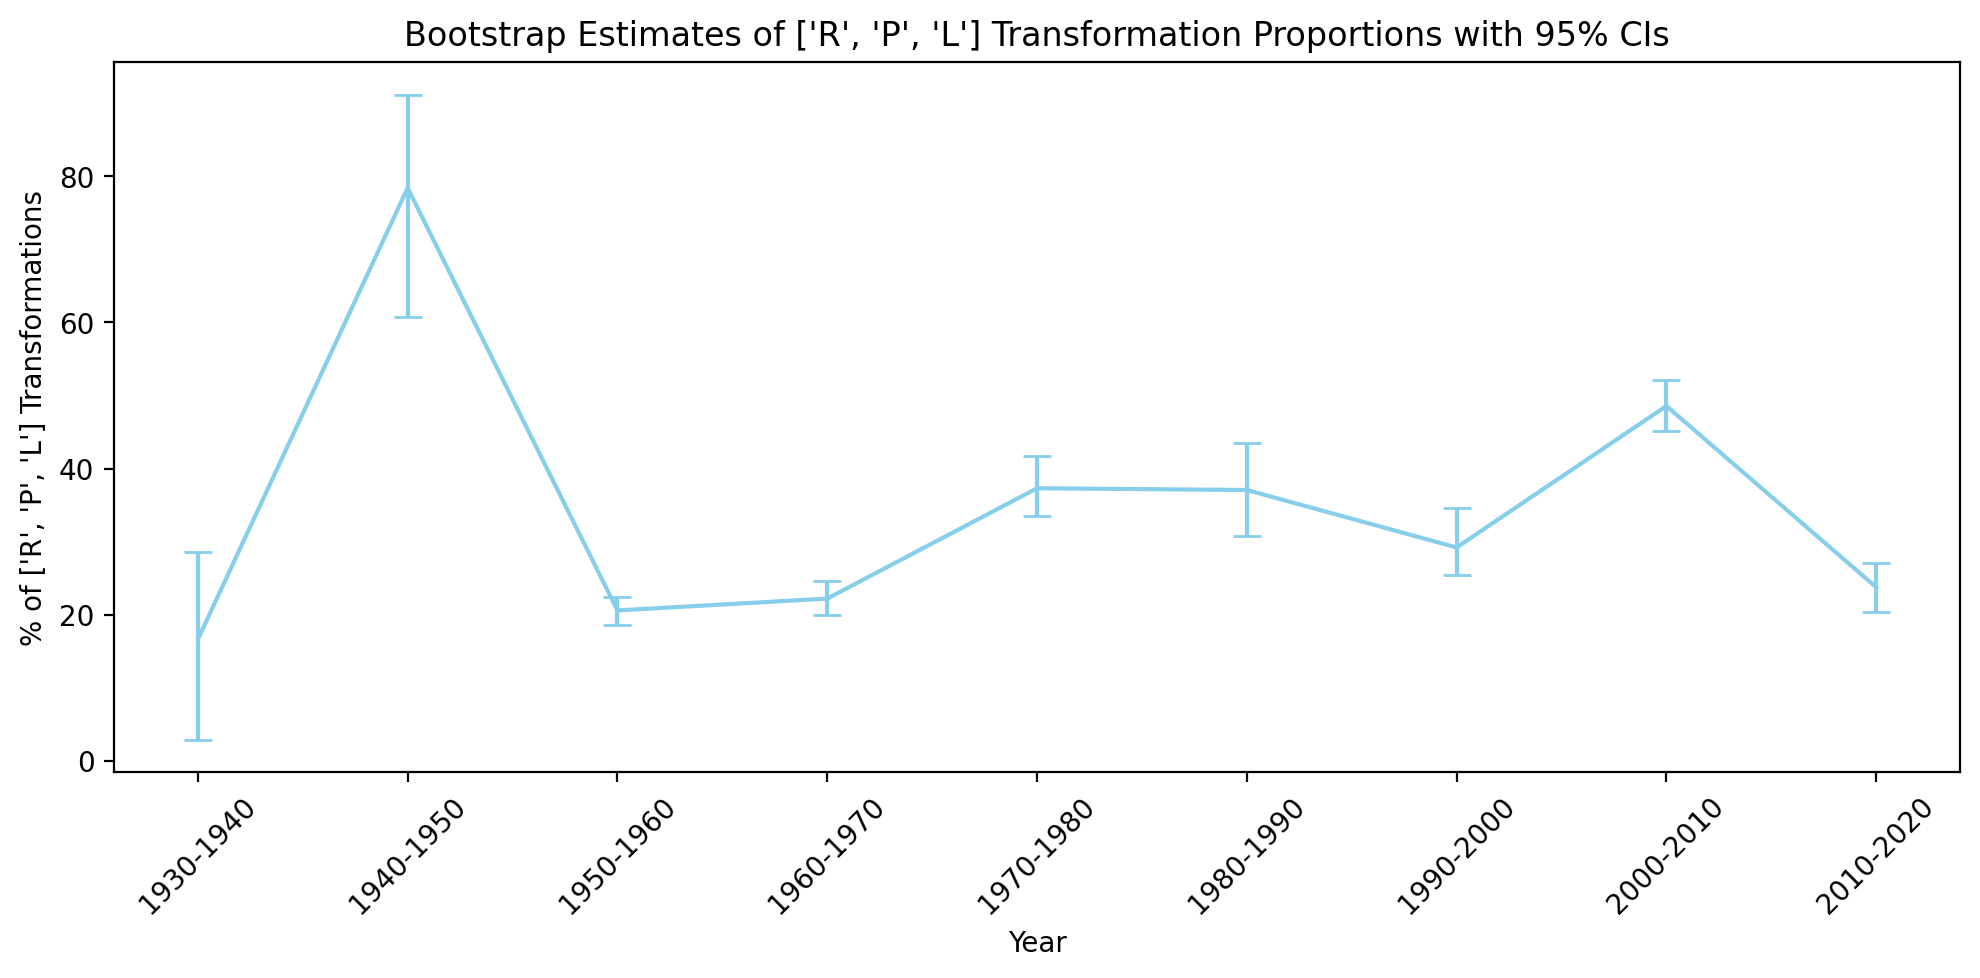

In [790]:
RPL = plot(['R','P','L'])

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_61742/10318916.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(P_results['year_bin'], rotation=45)


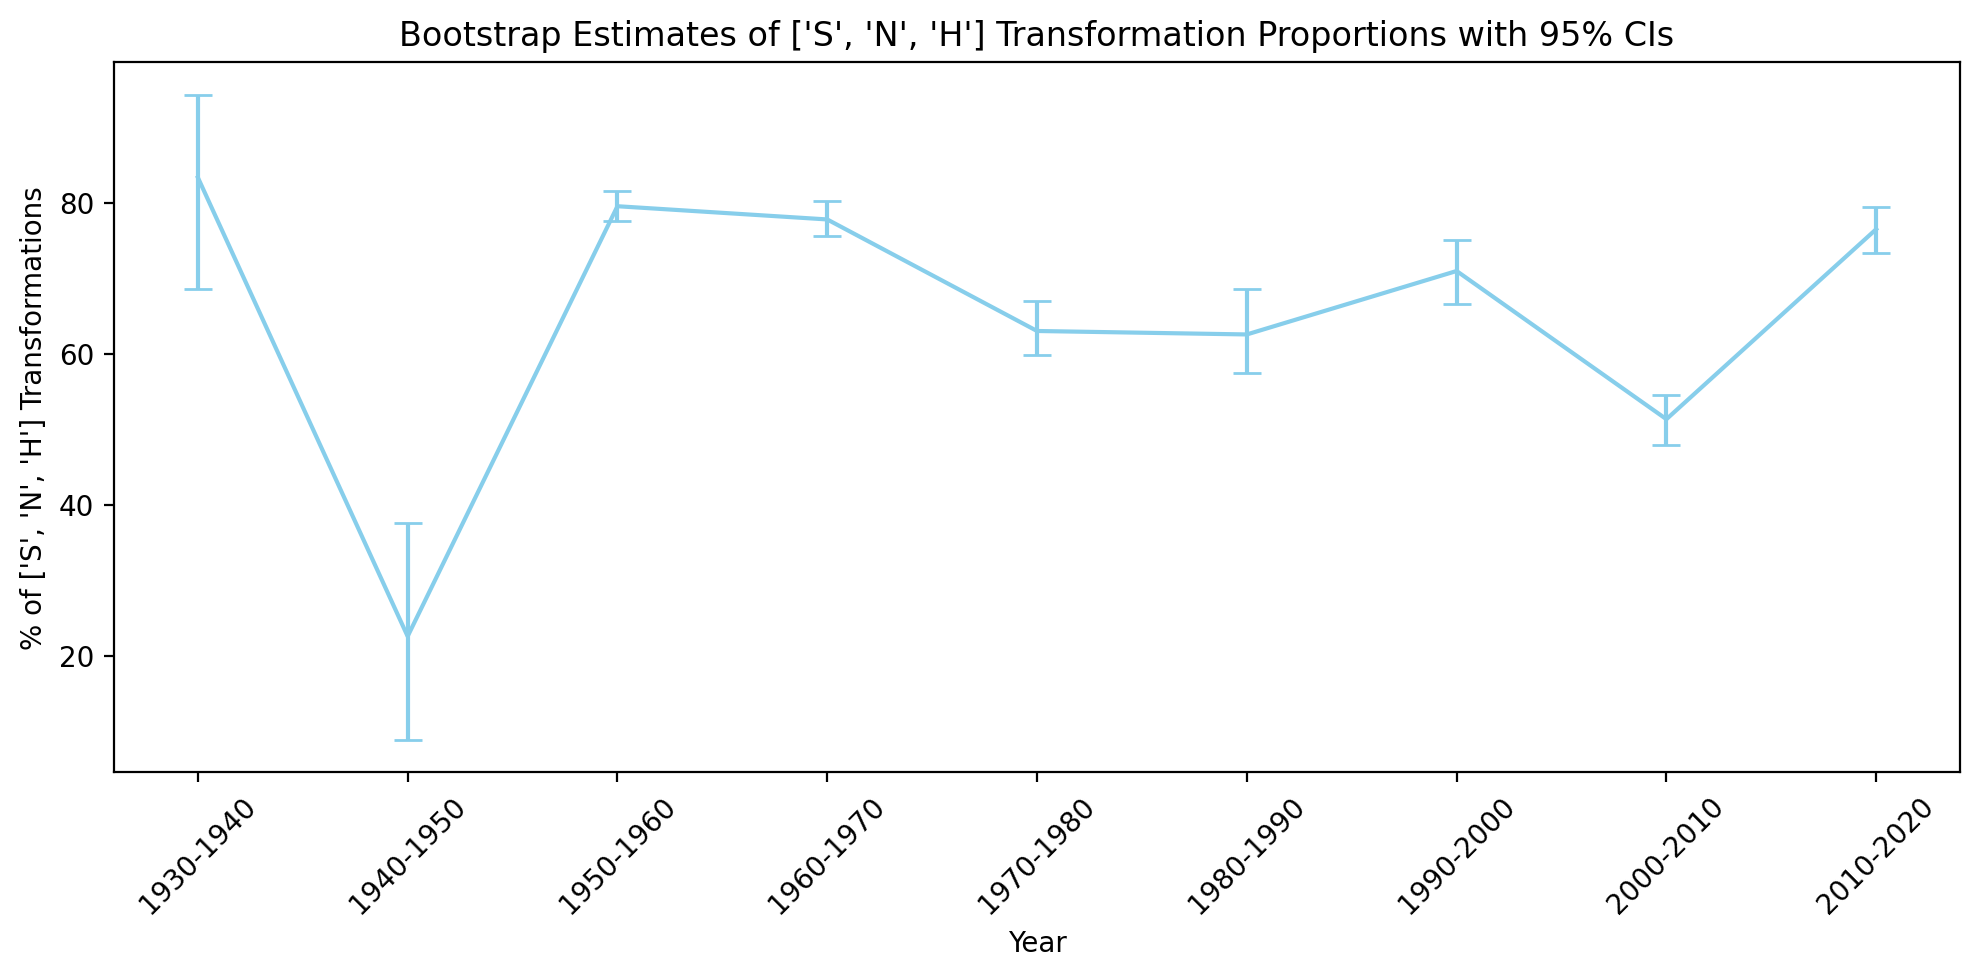

In [792]:
SNH = plot(['S','N','H'])

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_61742/10318916.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(P_results['year_bin'], rotation=45)


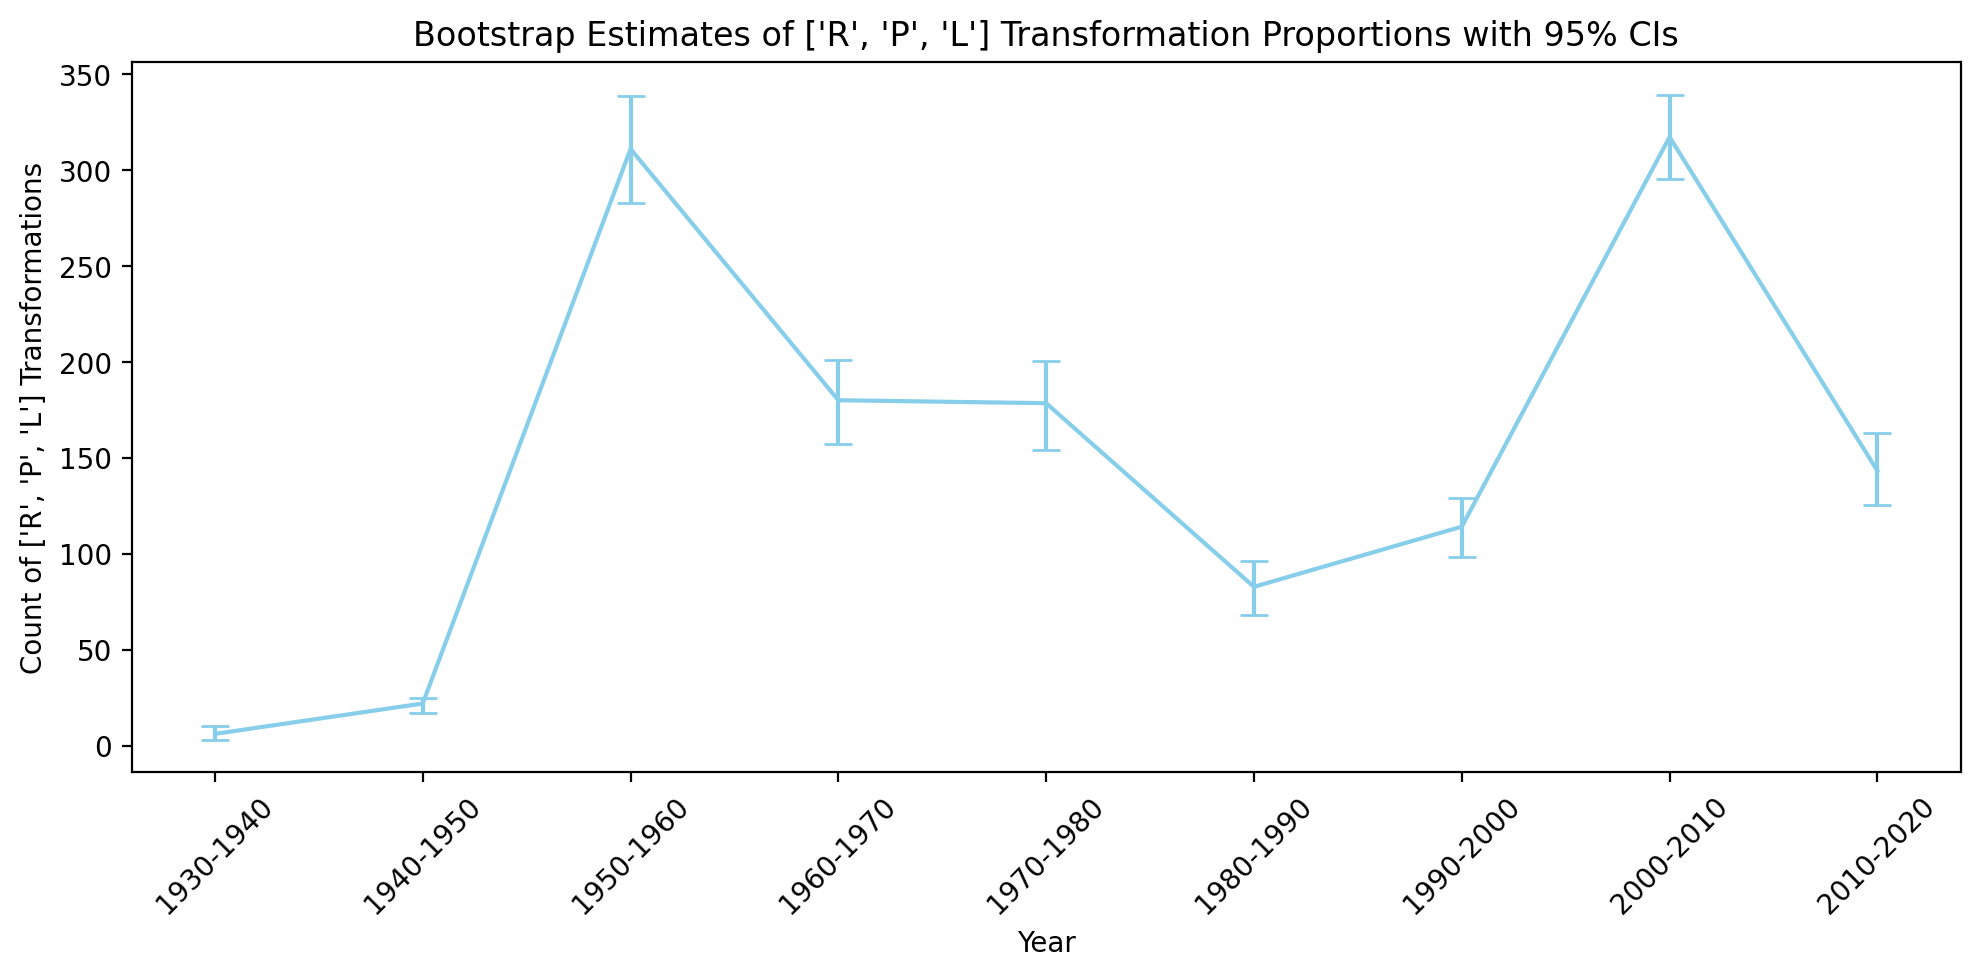

In [786]:
RPL = plot(['R','P','L'], y='Count')

/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_61742/10318916.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(P_results['year_bin'], rotation=45)


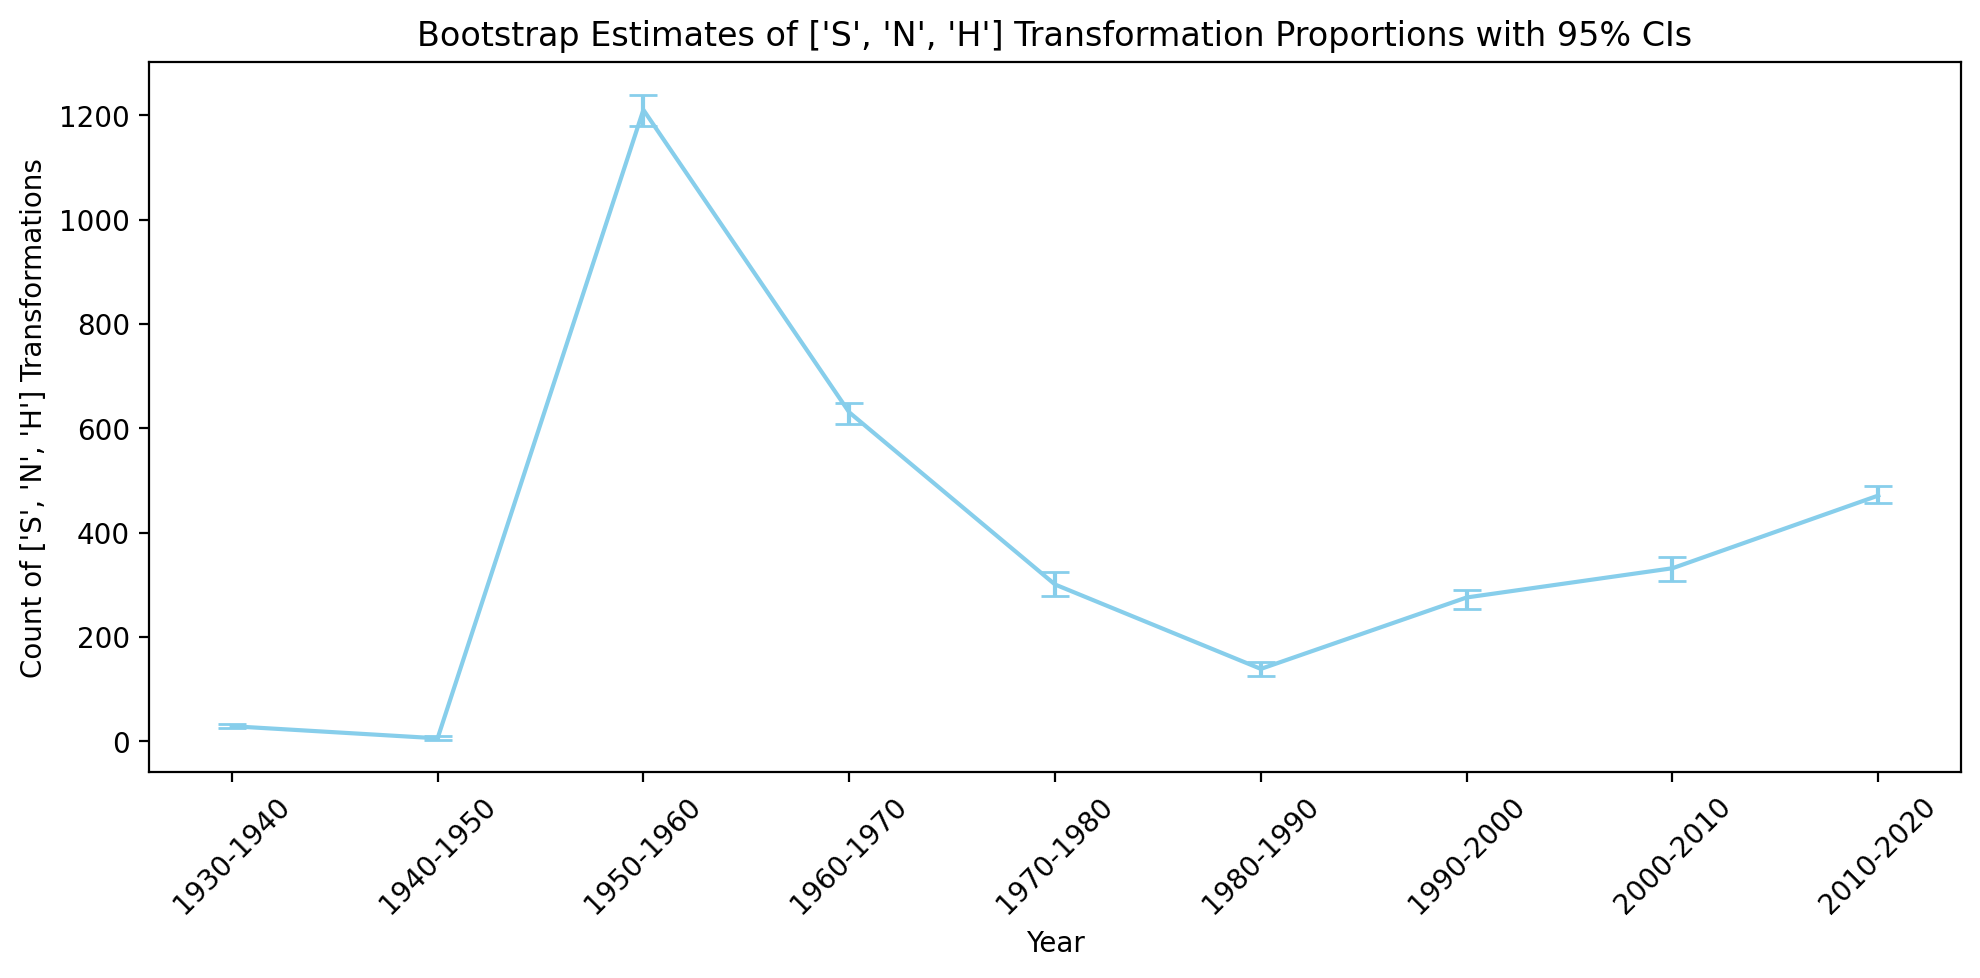

In [788]:
SNH = plot(['S','N','H'], y='Count')

## Observations
- 1930-1940: only data is from Coleman Hawkins
- 1940-1950: only data is from Charlie Parker
- 1950-1960: top N trans contributors are Miles davis (191/271) and Sonny Rollins (179/266) (Make artist percentage plots?)
- 1960-1970: N trans miles davis (15/24)


## Group by artist

1. Calculate the average % of each transformation globally (# transformation x / total transformations)
2. Calculate the average % of each transformation for each artist (# transformation x for artist y / total transformations for artist y)

In [564]:
list_transformations = ['R','P','L','S','N','H']

In [681]:
average_percentages=[]
tot_count = transformations_cut.shape[0]

for t in list_transformations:
    # bootstrap
    sample_mean = []
    for i in range(100):
        sub_samp = transformations_cut.sample(frac=1, replace=True)
        t_count = sub_samp[sub_samp['transformation'] == t].shape[0]
            
        avg = 100 * t_count / tot_count
        sample_mean.append(avg)

    average_percentages.append(sample_mean)
    

#### Picking top artists by % transformation for each artist normalized per tot transformation per artist

In [802]:
artists_labels = []
tot_count = transformations_cut['artist'].value_counts()
for t in list_transformations:
    subset = transformations[transformations['transformation'] == t]
    grouped_artists = subset['artist'].value_counts()

    artist_percentages = (grouped_artists / tot_count[grouped_artists.index]) * 100
    top_artists = artist_percentages.sort_values(ascending=False).head(3)
    for a in top_artists.index:
        if a not in artists_labels:
            artists_labels.append(a)

In [804]:
transformations_artists = transformations.copy()
    
#pattern = '|'.join(re.escape(artist) for artist in artists_labels)
# transformations_artists['artist'] = transformations_artists['artist'].where(transformations_artists['artist'].str.contains(pattern, na=False), 'Other')
transformations_artists['artist'] = transformations_artists['artist'].where(transformations_artists['artist'].isin(artists_labels), 'Other')
transformations_artists_cut = transformations_artists[transformations_artists['transformation'] != 'N/A']


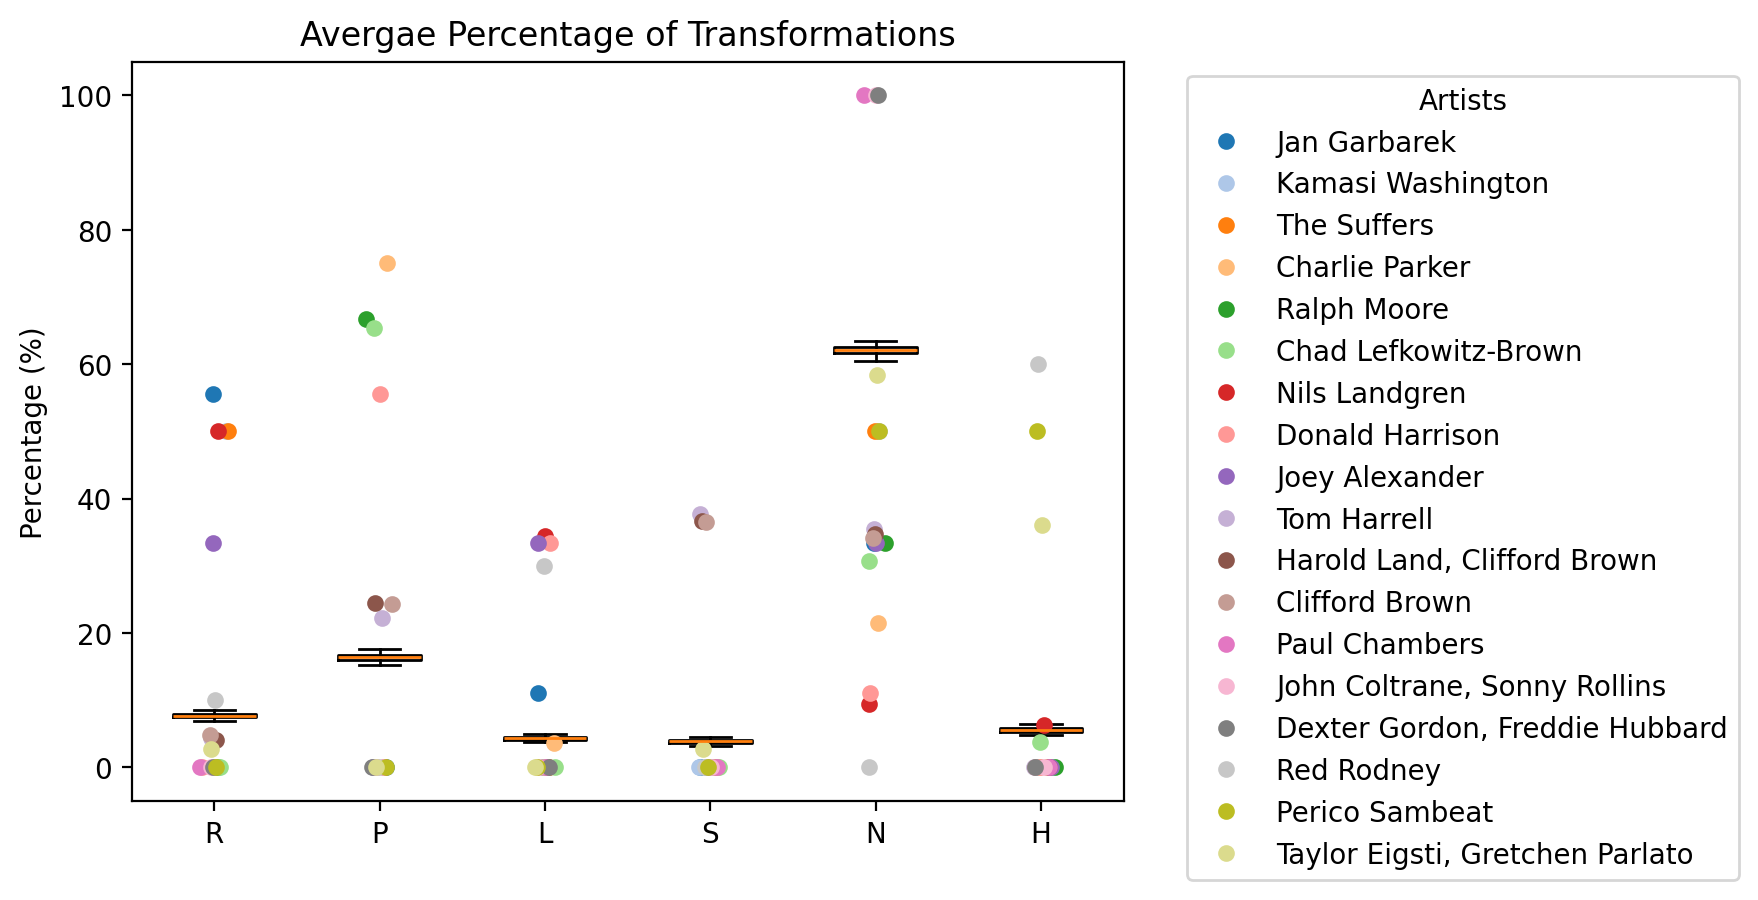

In [808]:
average_percentages_artists=[]

for t in list_transformations:
    t_avg = []
    for a in artists_labels:
        sub_samp = transformations_artists_cut[transformations_artists_cut['artist'] == a]
        # relative
        tot_count = sub_samp.shape[0]
        t_count = sub_samp[sub_samp['transformation'] == t].shape[0]

        if tot_count == 0:
            avg = 0  
        else:
            avg = 100 * t_count / tot_count
            
        t_avg.append(avg)

    average_percentages_artists.append(t_avg)

plt.boxplot(average_percentages, labels=list_transformations, showfliers=False)

colors = plt.cm.tab20.colors

for j, artist in enumerate(artists_labels):
    x_vals = []
    y_vals = []
    for i, points in enumerate(average_percentages_artists):
        x = np.random.normal(i+1, 0.04)  # jitter
        y = points[j]  # this artist’s point for this transformation
        x_vals.append(x)
        y_vals.append(y)
    plt.plot(x_vals, y_vals, 'o', label=artist, color=colors[j % len(colors)], markersize=5)
    
plt.ylabel('Percentage (%)')
plt.title('Avergae Percentage of Transformations')
plt.legend(title="Artists", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

#### Picking top artists by % transformation for each artist normalized per tot transformation per artist

In [816]:
artists_labels = []
for t in list_transformations:
    subset = transformations[transformations['transformation'] == t]
    grouped_artists = subset['artist'].value_counts()
    for a in grouped_artists.index[:5]:
        if a not in artists_labels:
            artists_labels.append(a)

In [818]:
transformations_artists = transformations.copy()
    
#pattern = '|'.join(re.escape(artist) for artist in artists_labels)
# transformations_artists['artist'] = transformations_artists['artist'].where(transformations_artists['artist'].str.contains(pattern, na=False), 'Other')
transformations_artists['artist'] = transformations_artists['artist'].where(transformations_artists['artist'].isin(artists_labels), 'Other')
transformations_artists_cut = transformations_artists[transformations_artists['transformation'] != 'N/A']


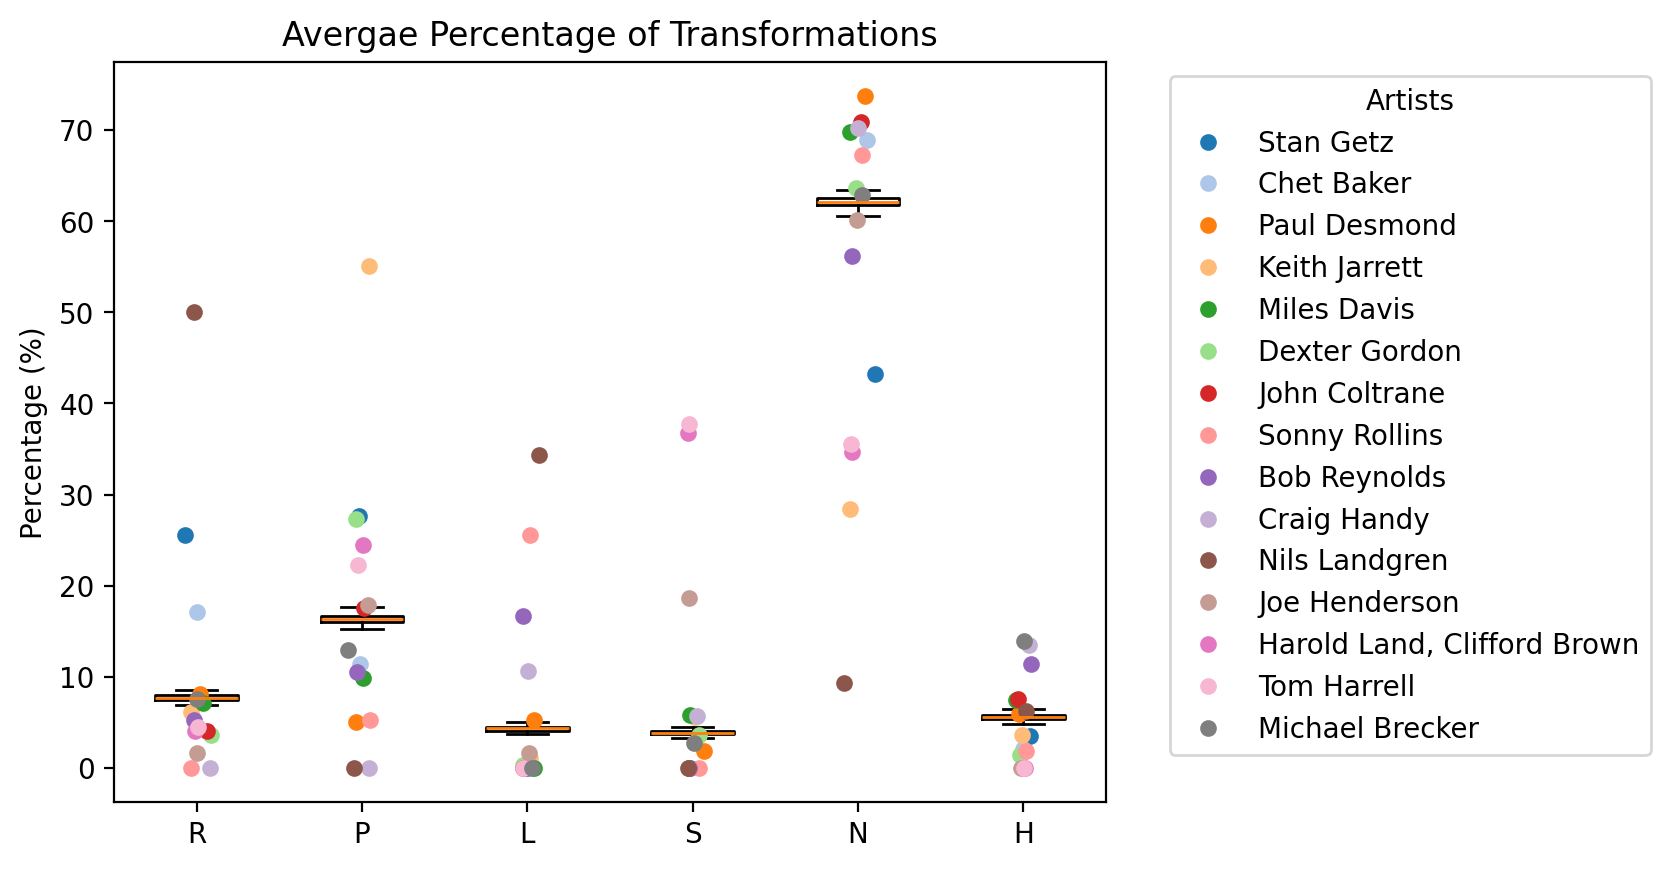

In [820]:
average_percentages_artists=[]

for t in list_transformations:
    t_avg = []
    for a in artists_labels:
        sub_samp = transformations_artists_cut[transformations_artists_cut['artist'] == a]
        # relative
        tot_count = sub_samp.shape[0]
        t_count = sub_samp[sub_samp['transformation'] == t].shape[0]

        if tot_count == 0:
            avg = 0  
        else:
            avg = 100 * t_count / tot_count
            
        t_avg.append(avg)

    average_percentages_artists.append(t_avg)

plt.boxplot(average_percentages, labels=list_transformations, showfliers=False)

colors = plt.cm.tab20.colors

for j, artist in enumerate(artists_labels):
    x_vals = []
    y_vals = []
    for i, points in enumerate(average_percentages_artists):
        x = np.random.normal(i+1, 0.04)  # jitter
        y = points[j]  # this artist’s point for this transformation
        x_vals.append(x)
        y_vals.append(y)
    plt.plot(x_vals, y_vals, 'o', label=artist, color=colors[j % len(colors)], markersize=5)
    
plt.ylabel('Percentage (%)')
plt.title('Avergae Percentage of Transformations')
plt.legend(title="Artists", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()